# Lab 6 — Diagnose It Yourself

Five datasets, `a` through `e`. Four of them were made by exactly one of the mechanisms from
Lecture 13 Part 2 — a **mixture** of two populations, **correlated** samples, a **heavy
tail**, or a **product** instead of a sum. One is a plain, ordinary normal sample with
nothing wrong with it.

Your job: say which is which, **including which one is fine**, and name the panel that gave
each one away. The generating code is deliberately not here.

Two things to know before you start:

* Each dataset comes with a `group` covariate, a 0/1 label. For all but one of them it is
  pure noise. Splitting by it is therefore a real diagnostic and not a giveaway.
* **Row order is meaningful. Do not sort or shuffle.** Two of the six panels read the order
  of the rows, and sorting destroys the evidence they look for.


The setup below is the toolkit from Lecture 13, unchanged, so this notebook runs on its own. Read it if you want to, but you do not need to modify any of it — everything you need is in `diagnose`.

In [14]:
%pip install numpy matplotlib scipy

  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
     |████████████████████████████████| 30.3 MB 4.3 MB/s eta 0:00:01
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached fonttools-4.60.2-cp39-cp39-macosx_10_9_universal2.whl (2.9 MB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
     |████████████████████████████████| 126 kB 15.6 MB/s eta 0:00:01
You should consider upgrading via the '/Users/doodles/Data-3402/jupyter-env/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
def hist_with_normal(x, bins=50, ax=None, label=None):
    if ax is None:
        ax = plt.gca()
    x = np.asarray(x)
    _, edges, _ = ax.hist(x, bins=bins, density=True, alpha=0.6, label=label)
    grid = np.linspace(edges[0], edges[-1], 300)
    ax.plot(grid, stats.norm.pdf(grid, np.mean(x), np.std(x)), "k--", label="normal, same mean & std")
    ax.legend(fontsize=8)

In [3]:
def qq_plot(x, ax=None, label=None):
    if ax is None:
        ax = plt.gca()
    x = np.sort(np.asarray(x))
    n = len(x)
    theoretical = stats.norm.ppf((np.arange(1, n + 1) - 0.5) / n)
    ax.scatter(theoretical, x, s=4, label=label)

    q25, q50, q75 = np.percentile(x, [25, 50, 75])
    slope = (q75 - q25) / (stats.norm.ppf(0.75) - stats.norm.ppf(0.25))
    ax.plot(theoretical, q50 + slope * theoretical, "k--", lw=1)
    ax.set_xlabel("normal quantile")
    ax.set_ylabel("data quantile")

In [4]:
def running_mean(x):
    x = np.asarray(x)
    return np.cumsum(x) / np.arange(1, len(x) + 1)

In [5]:
def autocorrelation(x, max_lag):
    x = np.asarray(x) - np.mean(x)
    denominator = np.sum(x * x)
    result = list()
    for lag in range(max_lag + 1):
        result.append(np.sum(x[:len(x) - lag] * x[lag:]) / denominator)
    return result

In [6]:
def diagnose(x, group=None, name=""):
    x = np.asarray(x)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(name)

    hist_with_normal(x, ax=axes[0, 0])
    axes[0, 0].set_title("histogram vs normal")

    qq_plot(x, ax=axes[0, 1])
    axes[0, 1].set_title("Q-Q plot")

    if np.all(x > 0):
        hist_with_normal(np.log(x), ax=axes[0, 2])
        axes[0, 2].set_title("histogram of log(x)")
    else:
        axes[0, 2].set_title("log: not possible (values <= 0)")

    axes[1, 0].plot(running_mean(x))
    axes[1, 0].set_title("running mean")

    axes[1, 1].plot(autocorrelation(x, 50), marker=".")
    axes[1, 1].axhline(0, color="k", lw=0.5)
    axes[1, 1].set_title("autocorrelation")

    if group is not None:
        bins = np.histogram_bin_edges(x, bins=40)
        axes[1, 2].hist(x[group == 0], bins=bins, alpha=0.5, density=True, label="group 0")
        axes[1, 2].hist(x[group == 1], bins=bins, alpha=0.5, density=True, label="group 1")
        axes[1, 2].legend()
    axes[1, 2].set_title("split by covariate")

    plt.tight_layout()
    plt.show()

Load the five datasets. Each name `x` has a partner `x_group` holding its covariate.

In [7]:
mystery = np.load("Lab.6.mystery.npz")
for name in ["a", "b", "c", "d", "e"]:
    print(name, mystery[name].shape)

a (1500,)
b (1500,)
c (1500,)
d (1500,)
e (1500,)


`diagnose` takes the data, its covariate, and a title. Here is the call for `a`; the reading of it is yours.

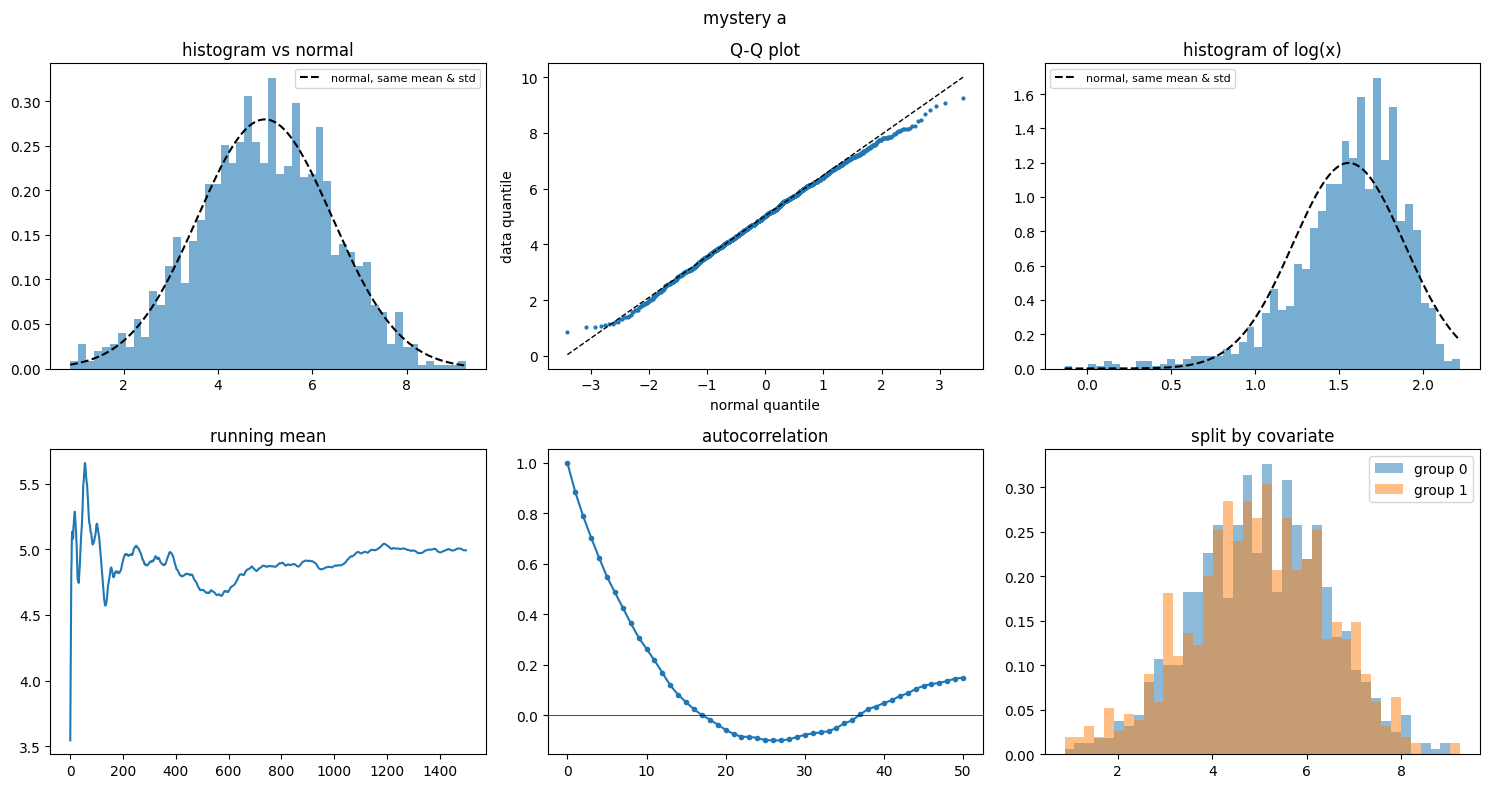

In [8]:
diagnose(mystery["a"], mystery["a_group"], "mystery a")

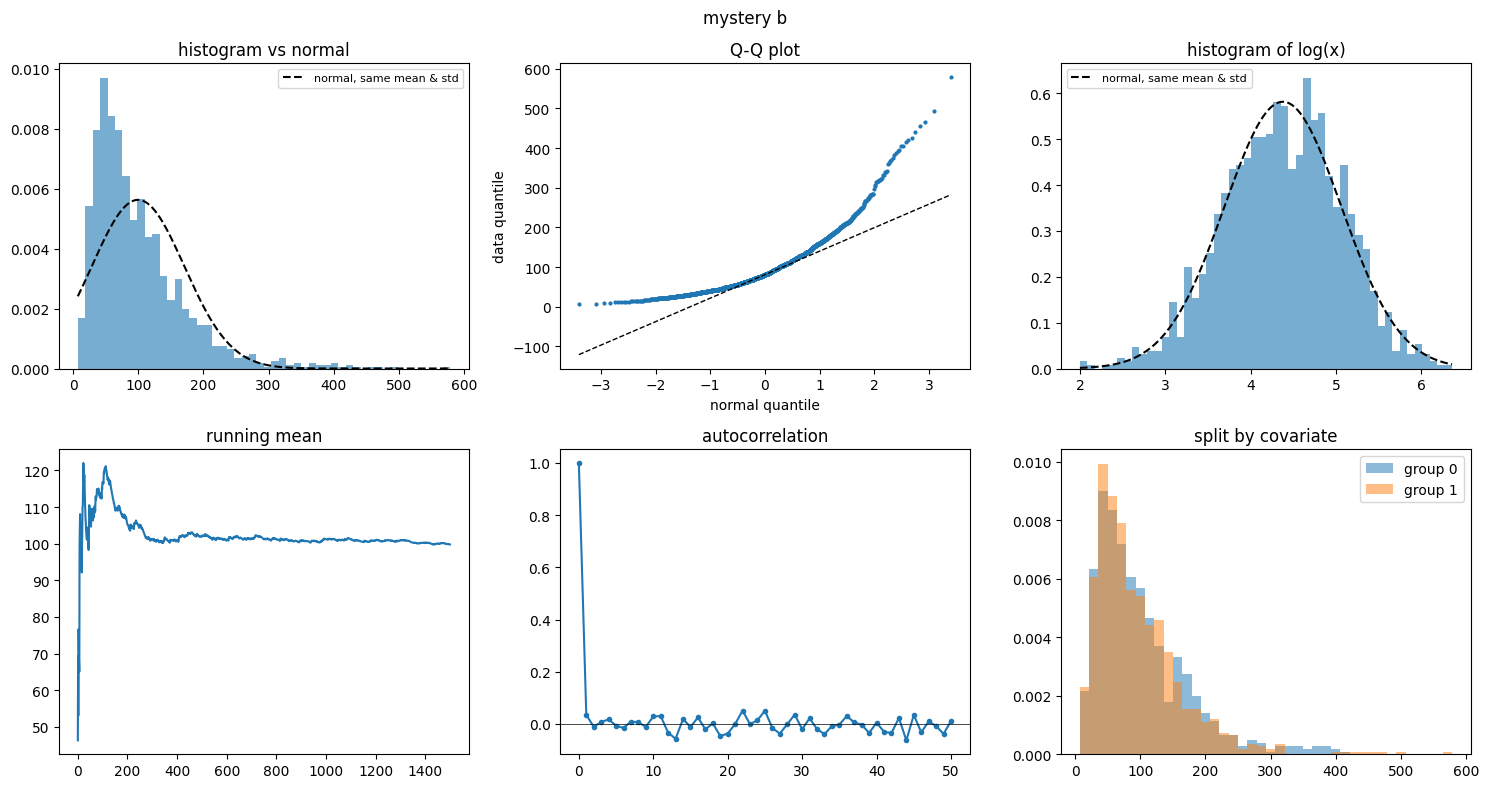

In [9]:
# mystery b
diagnose(mystery["b"], mystery["b_group"], "mystery b")

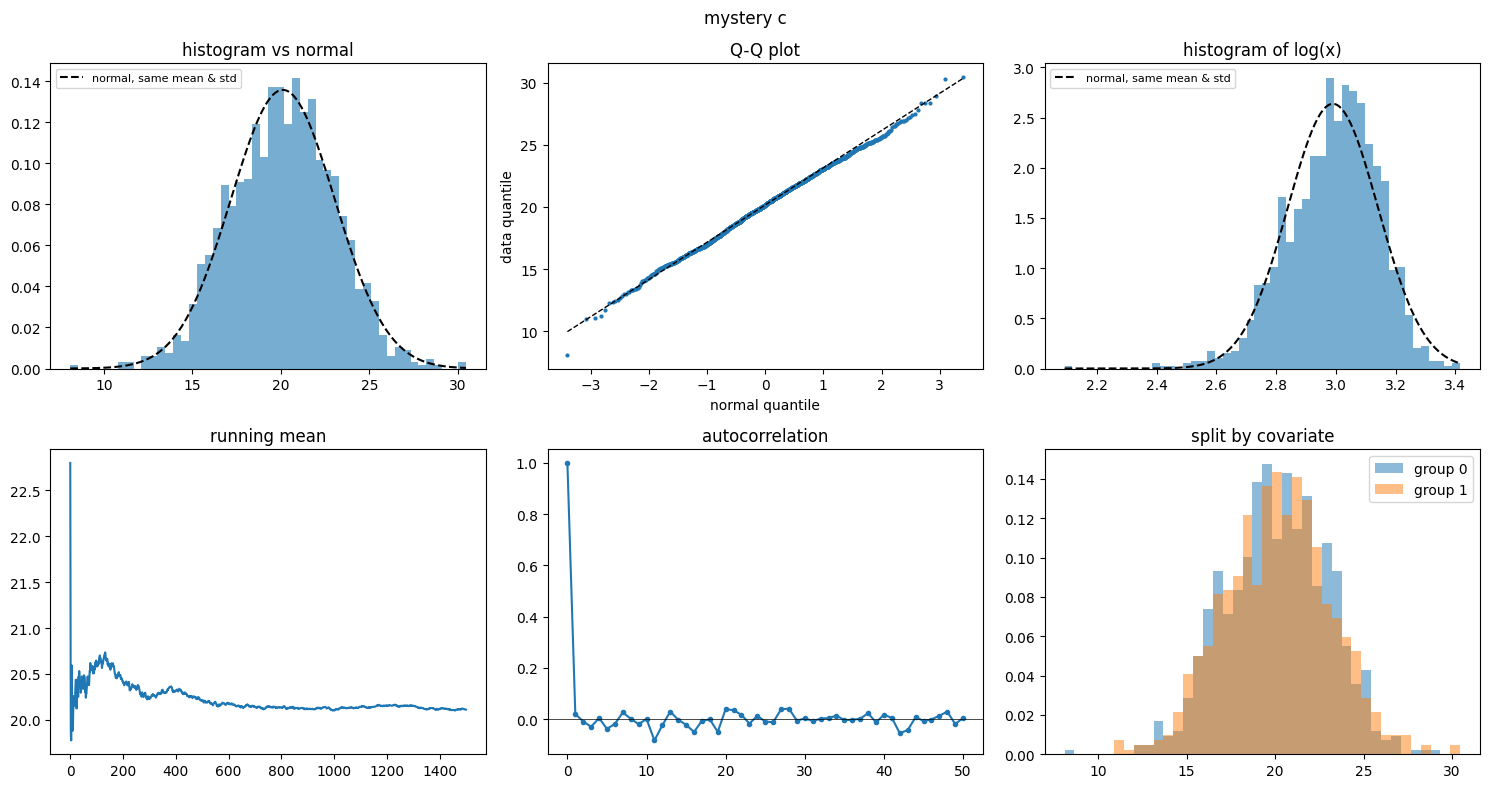

In [10]:
# mystery c
diagnose(mystery["c"], mystery["c_group"], "mystery c")

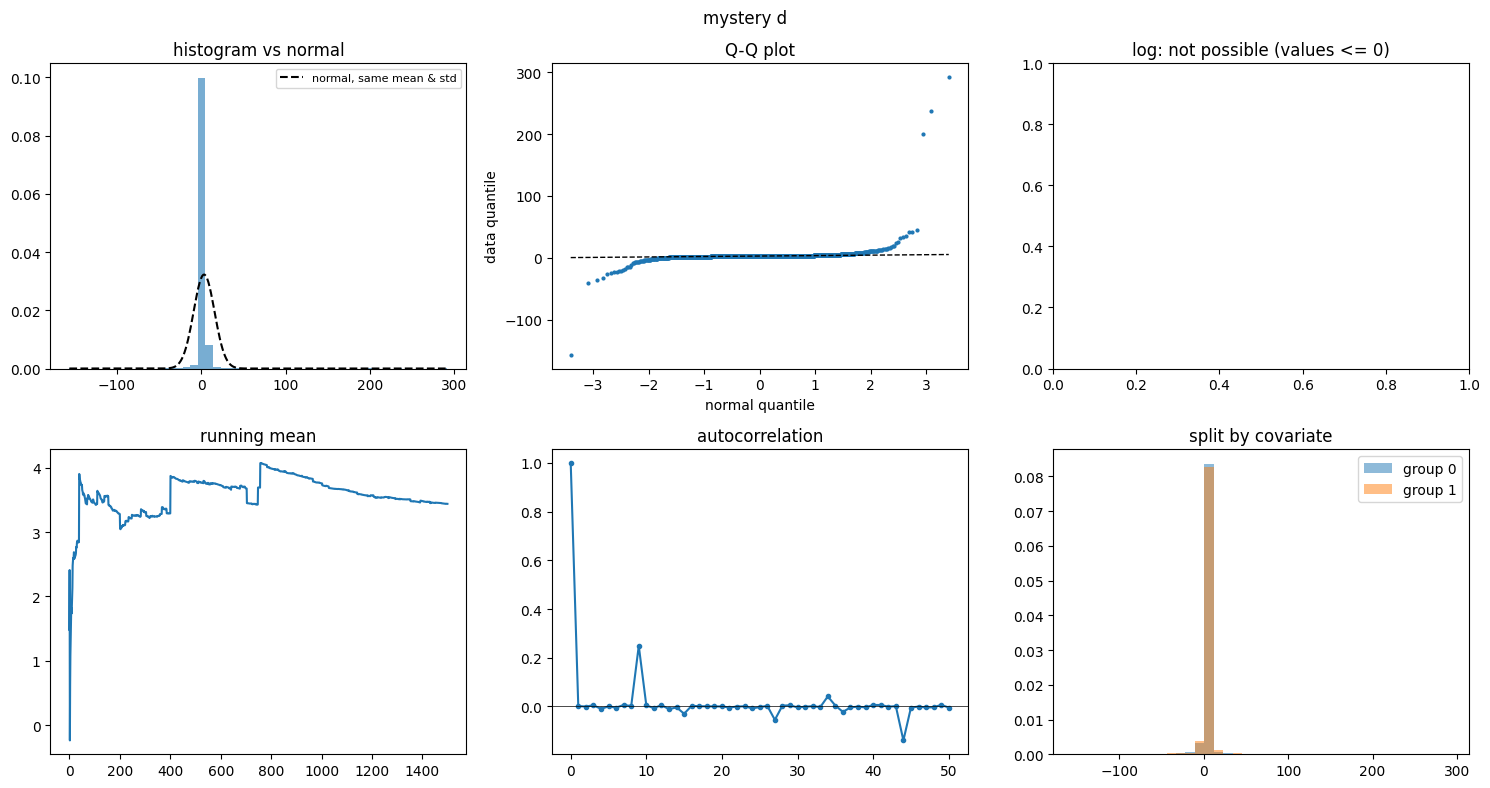

In [11]:
# mystery d
diagnose(mystery["d"], mystery["d_group"], "mystery d")

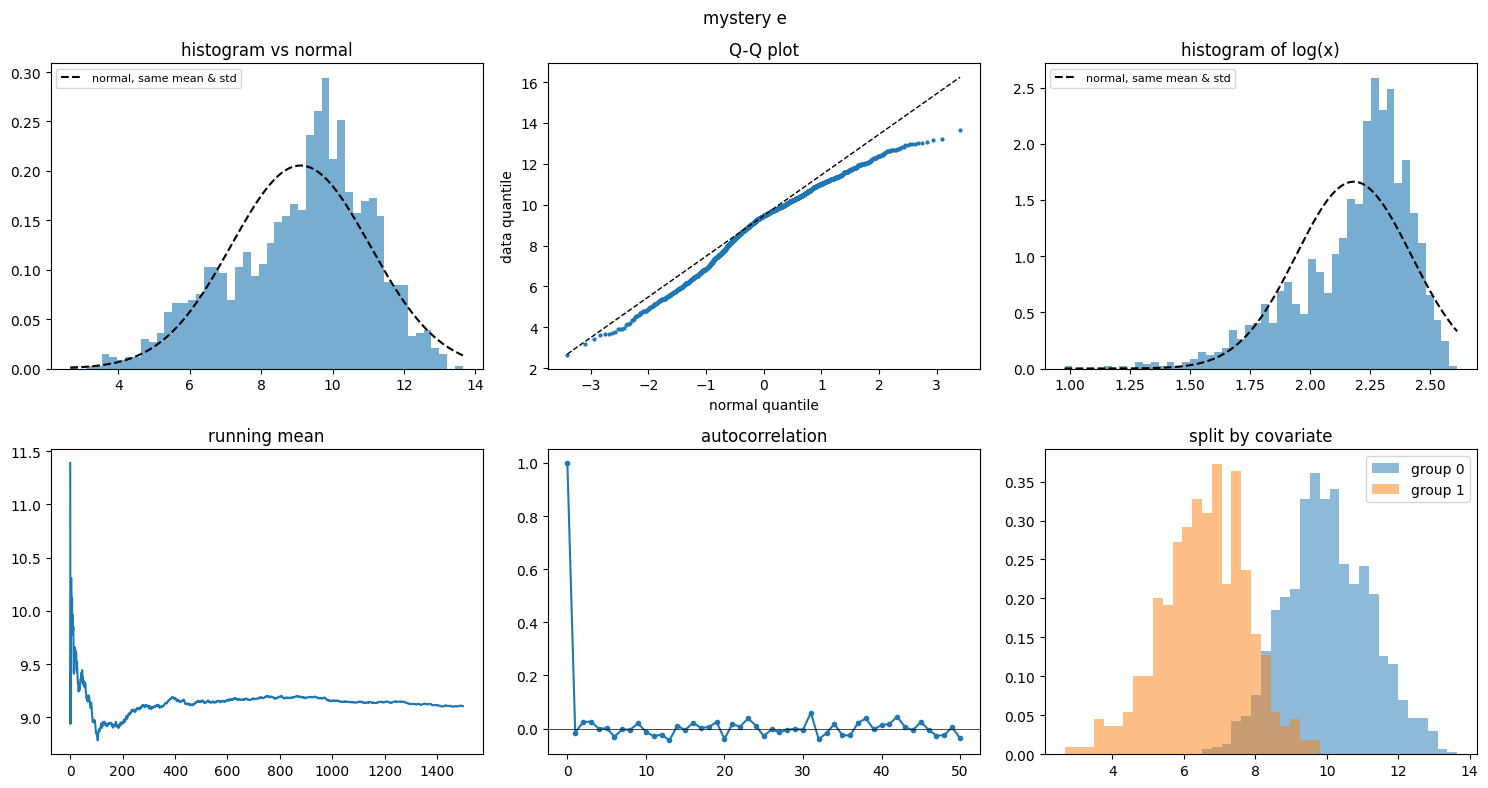

In [12]:
# mystery e
diagnose(mystery["e"], mystery["e_group"], "mystery e")

## What to hand in

Fill in the table, in this notebook. One line of reasoning per dataset is enough — what
matters is that the panel you name is the one that actually shows the problem.

| Dataset | Which assumption broke (or none) | Which panel told you | What you would do next with real data of this kind |
|---|---|---|---|
| `a` | the samples are correlated|The Autocorrelation graph |I'd look at the relationship of the data before analyzing it|
| `b` |a product instead of a sum|histogram of log(x)|analize the data on a log scale |
| `c` |none?| the q-q plot is very strait and the autocorrelation|just proceed normally|
| `d` |heavy tails, the extreme values are inconsistant with normal values|the q-q plot, both tails go fairly away from the reference line|look into the extreme observations, and try to use info that uses middle info (like median and iqr)|
| `e` |mixture of two populations|the two groups have different centers from split by covariate |analyize each group seperatly|

Two warnings, from the people who did this before you:

* One of the five passes every test of **shape** — its histogram and its Q–Q plot look
  perfectly normal. If you only look at the top row of panels, you will call it clean.
* Not every non-normal histogram is a broken assumption, and exactly one dataset here is
  fine. Resist diagnosing it anyway.
